# AirBnB NYC Analytics Project 

* Project by Nhi Bui · Villanova University · [GitHub](https://github.com/nhibui23/airbnb-saas-product-analytics) · [LinkedIn](https://linkedin.com/in/nhiuyenbui)

## 04. A/B Testing: Does Instant Bookable Drive Engagement?

> "Should Airbnb invest more in pushing hosts to enable Instant Bookable?"

Instant Bookable is one of Airbnb's flagship features, designed to remove friction from the booking process.  

Current assumption: turning it on should engage users more. This notebook tests that assumption using a Welch's t-test, effect size (Cohen's d), 95% confidence intervals, post-hoc power analysis, and KDE distribution plots.

**Key findings**
- Whether Instant Book listings get meaningfully more reviews than standard listings
- How confident we can be in that finding
- Whether the product team should keep investing in this feature

## Hypothesis
- H0 (Null): There is no significant difference in reviews per month 
  between instant bookable and non-instant bookable listings
- H1 (Alternative): Instant bookable listings generate significantly 
  more reviews per month than non-instant bookable listings

## Test Design
- Control group: instant_bookable = False
- Treatment group: instant_bookable = True
- Metric: reviews per month
- Significance level: α = 0.05

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

df = pd.read_csv('../data/Airbnb_Open_Data_Cleaned.csv')
print(df.shape)

(63718, 21)


# 1. Split data into 2 groups

In [2]:
#Split into 2 data groups based on instant_bookable
control = df[df['instant_bookable'] == 'False']['reviews per month']
treatment = df[df['instant_bookable'] == 'True']['reviews per month']

In [3]:
#Find mean of each group
print("Control Group Mean:", control.mean())
print("Treatment Group Mean:", treatment.mean())   

Control Group Mean: nan
Treatment Group Mean: nan


*Because both means are nan, we will check the data quality again*

In [4]:
#Check data type of column instant_bookable
print("Data type of 'instant_bookable' column:", df['instant_bookable'].dtype)  

Data type of 'instant_bookable' column: bool


In [5]:
#Check for missing values in 'reviews per month' and 'instant_bookable' columns
print(df['reviews per month'].isnull().sum())
print(df['instant_bookable'].isnull().sum())

0
0


In [6]:
#Check for data type values in control group
print(control.head(10))
print(control.dtype)

Series([], Name: reviews per month, dtype: float64)
float64


In [7]:
#Check for data type values in instant_bookable column
print(df['instant_bookable'].unique())
print(type(df['instant_bookable'].iloc[0]))

[False  True]
<class 'numpy.bool'>


*Because instant_bookable is numpy_boolean and not boolean, we will change our code*

In [8]:
#Divide instant_bookable column into 0 and 1 for control and treatment groups
control = df[df['instant_bookable'] == 0]['reviews per month']
treatment = df[df['instant_bookable'] == 1]['reviews per month']

In [9]:
#Find mean of each group
print("Control Group Mean:", control.mean())
print("Treatment Group Mean:", treatment.mean())

Control Group Mean: 1.6085153381867958
Treatment Group Mean: 1.621535026602483


In [10]:
#Find the number of observations in each group
print("Control Group Size:", control.count())
print("Treatment Group Size:", treatment.count())

Control Group Size: 32142
Treatment Group Size: 31576


### Key Takeaway

* Control (not instant bookable): 32,142 listings and 1.608 reviews/month

* Treatment (instant bookable): 31,576 listings and 1.621 reviews/month

=> A differenc of 0.013 reviews/month won't be a big difference for 2 groups

# 2. Check independence, normality and equal variance

* Normality: Wirh a large sample ize of 32K+ for each group, the samples are assumed to be normally distributed based on Central Limit Theorem
* Independence: Both groups are independent since one listing can't be both instant_bookable and not

In [11]:
#Check equal variances
print("Control Group Variance:", control.var())
print("Treatment Group Variance:", treatment.var())

Control Group Variance: 3.728536683735362
Treatment Group Variance: 3.2537891843946345


### Key Takeaway

Beacause the 2 variances are not equal (3.73 vs 3.25)

=> We should use Welch's t-test instead of a standard t-test

# 3. Welch's t-test

In [12]:
#Import statsmodels for t-test
from scipy import stats

In [13]:
#Perform t-test
t_stat, p_value = stats.ttest_ind(control, treatment, equal_var=False)  
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

T-statistic: -0.8797
P-value: 0.3790


### Key Takeaway

Based on Welch's t-stat: p-value: 0.379 > 0.05 

=> There is not enough evidence to say instant bookable leads to more reviews

=> The difference of 0.013 reviews/month is likely just random chance, not a real effect

=> Fail to reject null hypothesis

# 4. Check Cohen's d Effect Size

To assess practical significance beyond statistical significance, we calculate Cohen's d, which measures the difference relative to the variability in the data.

In [14]:
#Cohen's d calculation
cohen_d = (control.mean() - treatment.mean()) / np.sqrt((control.var() + treatment.var()) / 2)
print(f"Cohen's d: {cohen_d:.4f}")

Cohen's d: -0.0070


### Key Takeaway

* A -0.007 number is a very small effect size

=> Even if we had found statistical significance, the practical impact would be negligible

=> Instant Bookable likely has no meaningful effect on reviews

# 5. Power Analysis
To verify whether our test had the ability to detect a real effect if one existed, we conduct a power analysis using our sample size, effect size, and significance level.

In [15]:
#Calculate statistical power
from statsmodels.stats.power import TTestIndPower

power_analysis = TTestIndPower()
power = power_analysis.solve_power(
    effect_size=abs(cohen_d),
    nobs1=len(control),
    alpha=0.05,
    alternative='two-sided'
)
print(f"Statistical Power: {power:.4f}")

Statistical Power: 0.1431


### Key Takeaway


* Power Analysis Result: 0.1431 (14.3%)

* The low statistical power is not due to insufficient sample size (as 32K+ data points per group is very large), but rather because the effect size is negligibly small (Cohen's d = 0.007)

=> Instant Bookable has no meaningful  impact on review engagement, as the effect is simply too small to matter from a business perspective

# 6. Confidence Interval
 To validate our t-test result, we calculate the 95% confidence interval to determine the range of plausible true differences between the two groups.

In [16]:
import scipy.stats as stats

confidence_interval = stats.ttest_ind(control, treatment, equal_var=False)
ci = confidence_interval.confidence_interval(confidence_level=0.95)

print(f"95% Confidence Interval: ({ci.low:.4f}, {ci.high:.4f})")

95% Confidence Interval: (-0.0420, 0.0160)


### Key Takeaway

* 95% Confidence Interval: (-0.0420, 0.0160)

The confidence interval contains zero, meaning the true difference 
between groups could be positive, negative, or zero

=> We can't conclude that instant bookable has any directional effect on review engagement

# 7. KDE Plot
Finally, the KDE plot shows the shape of a distribution as a smooth curve to compare control vs treatment visually.

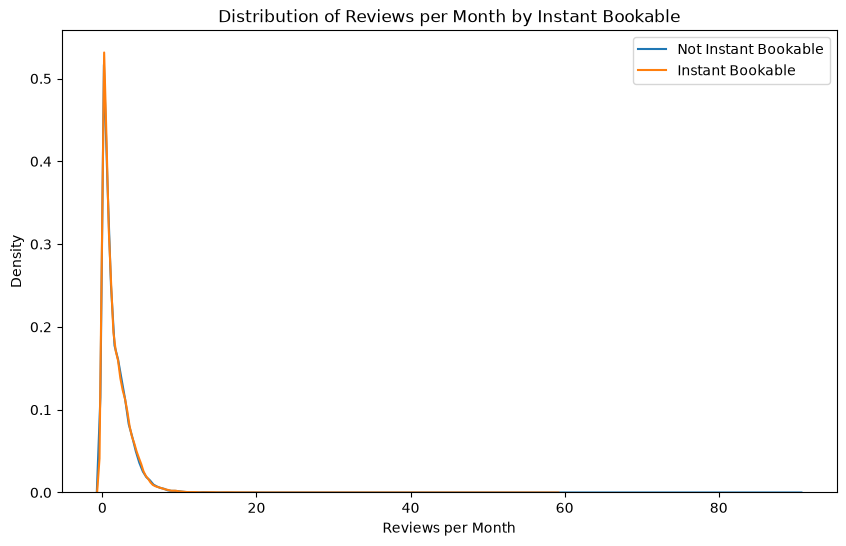

In [17]:
#Visualize the distribution of reviews per month for both groups
plt.figure(figsize=(10, 6))
sns.kdeplot(control, label='Not Instant Bookable')
sns.kdeplot(treatment, label='Instant Bookable')
plt.title('Distribution of Reviews per Month by Instant Bookable')
plt.xlabel('Reviews per Month')
plt.legend()
plt.show()

### Key Takeaway

* Both groups have nearly identical distributions, since its line overlaps each other

=> Confirm our assumption from t-test, Cohen's d, power analysis, and confidence interval 

* Both groups are heavily right-skewed

=> Most listings get very few reviews per month (clustered near 0), with a long tail at 20-80+ reviews

=> Review engagement is dominated by a small number of high-performing listings regardless of instant bookable status

# A/B Test Conclusion

**Hypotheses:**
- H0 (Null): There is no significant difference in reviews per month between instant bookable and non-instant bookable listings
- H1 (Alternative): Instant bookable listings generate significantly more reviews per month than non-instant bookable listings

**Results (Welch's T-Test):**
- T-statistic: -0.8797
- P-value: 0.3790 > 0.05 (not significant)
- Group difference: 0.013 reviews/month (Control: 1.608 & Treatment: 1.621)

**Secondary Evidence:**
- Cohen's d: -0.0070 (small effect size)
- Statistical Power: 14.3% (low power driven by small effect size)
- 95% Confidence Interval: (-0.0420, 0.0160) 
- KDE distribution: we see an overlap between groups

**Decision: Fail to reject H0**

All 4 of our validation tests consistently confirm that the difference between groups is statistically insignificant and attributable to random variation rather than a real effect of the Instant Book feature.

**Future Implementation:**
We conclude enabling Instant Bookable doesn't meaningfully drive higher review engagement

=> Airbnb should push priority from Instant Bookable to other higher-impact factors identified in the EDA, specifically **room type positioning** and **pricing strategy optimization** with stronger relationships with review performance

**Next steps**

Sine the number of reviews just tells us how old the listing is, as a listing that's been active for 5 years will likely have more total reviews than a new one, regardless of instant bookable, conducting the same A/B testing for this weaker metric will show less significance statistically to our hypothesis. 